In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Find the folder that directly contains "Original Data"
# (your dataset is nested twice, this handles it)
DRIVE_ROOT = None
BASE = '/content/drive/MyDrive'

for cur, dirs, files in os.walk(BASE):
    if cur.count('/') - BASE.count('/') > 4:
        dirs[:] = []
        continue
    if 'Original Data' in dirs:
        DRIVE_ROOT = cur
        break

print('DRIVE_ROOT:', DRIVE_ROOT)
print(os.listdir(DRIVE_ROOT))

Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive/LabEquipVis An Image Dataset of Computer Laborator
['Original Data', 'Augmented Data']


In [2]:
import random
import shutil
import time

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device: cuda


In [3]:
# Copy "Original Data" from Drive to the local Colab disk.
# Reading thousands of files straight from Drive is very slow,
# so we copy once and work locally after that.
# Takes a few minutes. Run it only once.

SRC = os.path.join(DRIVE_ROOT, 'Original Data')
LOCAL = '/content/original_data'

t0 = time.time()
if not os.path.exists(LOCAL):
    shutil.copytree(SRC, LOCAL)
print('copy done in %.1f minutes' % ((time.time() - t0) / 60))
print(os.listdir(LOCAL))


copy done in 1.8 minutes
['train', 'test', 'valid']


In [4]:
# Build the list of (image, label, split) from the local copy

def sub(parent, key):
    for name in os.listdir(parent):
        if name.lower() == key:
            return os.path.join(parent, name)
    return None

items = []
for cur, dirs, files in os.walk(LOCAL):
    low = [d.lower() for d in dirs]
    if 'images' not in low or 'labels' not in low:
        continue

    img_dir = sub(cur, 'images')
    lbl_dir = sub(cur, 'labels')

    folder = os.path.basename(cur).lower()
    if 'train' in folder:
        split = 'train'
    elif 'val' in folder:
        split = 'val'
    elif 'test' in folder:
        split = 'test'
    else:
        continue

    for fname in os.listdir(img_dir):
        name = os.path.splitext(fname)[0]
        lbl = os.path.join(lbl_dir, name + '.txt')
        if os.path.exists(lbl):
            items.append([os.path.join(img_dir, fname), lbl, split])

print('total images:', len(items))
for s in ['train', 'val', 'test']:
    print(s, ':', sum(1 for x in items if x[2] == s))


total images: 2584
train : 1809
val : 516
test : 259


In [5]:
# Class names in YOLO id order (from the dataset readme)

CLASS_NAMES = ['AC', 'Chair', 'CPU', 'Digital_Board', 'Fire_Extinguisher',
               'Keyboard', 'Light', 'Monitor', 'Mouse', 'Projector']

ids = set()
boxes = 0
for img_path, lbl_path, split in items:
    for line in open(lbl_path):
        if line.strip():
            ids.add(int(line.split()[0]))
            boxes += 1

print('class ids found:', sorted(ids))
print('names given    :', len(CLASS_NAMES))
print('total boxes    :', boxes)



class ids found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
names given    : 10
total boxes    : 47238


"""
## Turning a detection dataset into a classification dataset

LabEquipVis is annotated in YOLO format: every image has a `.txt` file with one
line per object (`class_id  cx  cy  w  h`, normalised 0-1). One laboratory photo
usually contains several different items at once (monitor, keyboard, mouse, CPU),
so the whole image cannot carry a single class label.

So we cut every annotated box out of its image and save it as a small square
image inside a folder named after its class:

`lab_cls/train/Monitor/...`, `lab_cls/train/Keyboard/...` and so on.

Boxes smaller than 32x32 pixels are skipped because they are too blurry to learn
anything from. The official 70/20/10 split of the dataset is kept, and crops from
one photo always stay inside the same split, so no image leaks from training into
validation or test.

Only the **Original Data** folder is used. The dataset's own "Augmented Data"
folder is left out on purpose: this assignment requires the transformations to be
applied by us (Round 2), and mixing in ready-made augmented copies of the same
photos would put nearly identical images in both training and validation.
"""

In [6]:
# Crop every labelled object and save it into class folders.
# Takes a few minutes. draft() decodes the JPEGs at reduced size, which is
# much faster and is fine because every crop is resized to 128x128 anyway.

IMG_SIZE = 128
OUT = '/content/lab_cls'

shutil.rmtree(OUT, ignore_errors=True)

count = 0
done = 0
for img_path, lbl_path, split in items:
    img = Image.open(img_path)
    img.draft('RGB', (1200, 1200))
    img = img.convert('RGB')

    W, H = img.size
    name = os.path.splitext(os.path.basename(img_path))[0]

    k = 0
    for line in open(lbl_path):
        parts = line.split()
        if len(parts) < 5:
            continue

        cid = int(parts[0])
        cx = float(parts[1]) * W
        cy = float(parts[2]) * H
        bw = float(parts[3]) * W
        bh = float(parts[4]) * H

        x1 = max(0, int(cx - bw / 2))
        y1 = max(0, int(cy - bh / 2))
        x2 = min(W, int(cx + bw / 2))
        y2 = min(H, int(cy + bh / 2))

        if x2 - x1 < 32 or y2 - y1 < 32:
            continue

        if cid < len(CLASS_NAMES):
            cname = CLASS_NAMES[cid]
        else:
            cname = 'class_' + str(cid)

        folder = os.path.join(OUT, split, cname)
        os.makedirs(folder, exist_ok=True)

        crop = img.crop((x1, y1, x2, y2)).resize((IMG_SIZE, IMG_SIZE))
        crop.save(os.path.join(folder, name + '_' + str(k) + '.jpg'))
        k += 1
        count += 1

    done += 1
    if done % 300 == 0:
        print(done, '/', len(items), 'images ->', count, 'crops')

print('total crops saved:', count)


300 / 2584 images -> 4821 crops
600 / 2584 images -> 9610 crops
900 / 2584 images -> 14373 crops
1200 / 2584 images -> 19076 crops
1500 / 2584 images -> 23804 crops
1800 / 2584 images -> 28416 crops
2100 / 2584 images -> 33061 crops
2400 / 2584 images -> 37725 crops
total crops saved: 40596


In [7]:
# How many crops per class in each split

for split in ['train', 'val', 'test']:
    print('-----', split)
    total = 0
    for c in sorted(os.listdir(os.path.join(OUT, split))):
        n = len(os.listdir(os.path.join(OUT, split, c)))
        total += n
        print(c, ':', n)
    print('total :', total)
    print()

----- train
AC : 158
CPU : 2616
Chair : 5927
Digital_Board : 136
Fire_Extinguisher : 334
Keyboard : 2314
Light : 672
Monitor : 11167
Mouse : 5097
Projector : 123
total : 28544

----- val
AC : 36
CPU : 722
Chair : 1649
Digital_Board : 29
Fire_Extinguisher : 102
Keyboard : 662
Light : 197
Monitor : 3116
Mouse : 1420
Projector : 37
total : 7970

----- test
AC : 9
CPU : 321
Chair : 837
Digital_Board : 21
Fire_Extinguisher : 42
Keyboard : 351
Light : 90
Monitor : 1676
Mouse : 717
Projector : 18
total : 4082



In [8]:
# ROUND 1 data pipeline: resize + ToTensor only, no augmentation

BATCH_SIZE = 64

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(OUT + '/train', transform=basic_transform)
val_data = datasets.ImageFolder(OUT + '/val', transform=basic_transform)
test_data = datasets.ImageFolder(OUT + '/test', transform=basic_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_data.classes
num_classes = len(class_names)

print('classes:', class_names)
print('train:', len(train_data), ' val:', len(val_data), ' test:', len(test_data))


classes: ['AC', 'CPU', 'Chair', 'Digital_Board', 'Fire_Extinguisher', 'Keyboard', 'Light', 'Monitor', 'Mouse', 'Projector']
train: 28544  val: 7970  test: 4082


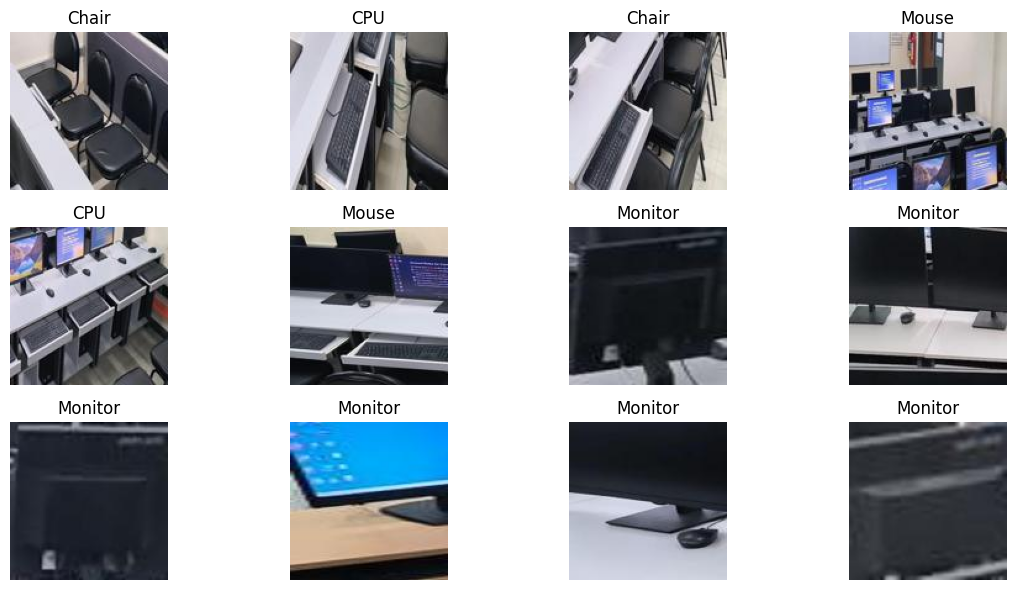

In [9]:
# Look at a few training images

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# The CNN: 3 conv blocks + a small classification head

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, p_drop=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p_drop)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))    # 64  -> 32
        x = self.pool(F.relu(self.conv3(x)))    # 32  -> 16
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model1 = SimpleCNN(num_classes, p_drop=0.0).to(device)
print(model1)
print('parameters:', sum(p.numel() for p in model1.parameters()))


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
parameters: 2122154


In [11]:
# Training and validation loops

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def validate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def run_training(model, tr_loader, va_loader, epochs):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        tr_loss, tr_acc = train_epoch(model, tr_loader, optimizer, criterion)
        va_loss, va_acc = validate_epoch(model, va_loader, criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        print('Epoch', epoch + 1, '/', epochs,
              '| train_loss %.4f' % tr_loss, 'train_acc %.4f' % tr_acc,
              '| val_loss %.4f' % va_loss, 'val_acc %.4f' % va_acc)

    return history



In [13]:
# ROUND 1: no augmentation, no dropout

EPOCHS = 20
history1 = run_training(model1, train_loader, val_loader, EPOCHS)


Epoch 1 / 20 | train_loss 1.3022 train_acc 0.5071 | val_loss 1.1054 val_acc 0.5731
Epoch 2 / 20 | train_loss 1.0176 train_acc 0.6138 | val_loss 0.9858 val_acc 0.6243
Epoch 3 / 20 | train_loss 0.8494 train_acc 0.6764 | val_loss 0.9038 val_acc 0.6581
Epoch 4 / 20 | train_loss 0.6964 train_acc 0.7364 | val_loss 0.9488 val_acc 0.6563
Epoch 5 / 20 | train_loss 0.5342 train_acc 0.7984 | val_loss 0.9706 val_acc 0.6801
Epoch 6 / 20 | train_loss 0.3793 train_acc 0.8587 | val_loss 1.0829 val_acc 0.6799
Epoch 7 / 20 | train_loss 0.2474 train_acc 0.9133 | val_loss 1.2627 val_acc 0.6669
Epoch 8 / 20 | train_loss 0.1629 train_acc 0.9428 | val_loss 1.4858 val_acc 0.6735
Epoch 9 / 20 | train_loss 0.1141 train_acc 0.9617 | val_loss 1.7116 val_acc 0.6713
Epoch 10 / 20 | train_loss 0.0823 train_acc 0.9745 | val_loss 1.8773 val_acc 0.6565
Epoch 11 / 20 | train_loss 0.0791 train_acc 0.9746 | val_loss 1.8827 val_acc 0.6567
Epoch 12 / 20 | train_loss 0.0696 train_acc 0.9802 | val_loss 2.1007 val_acc 0.6560
E

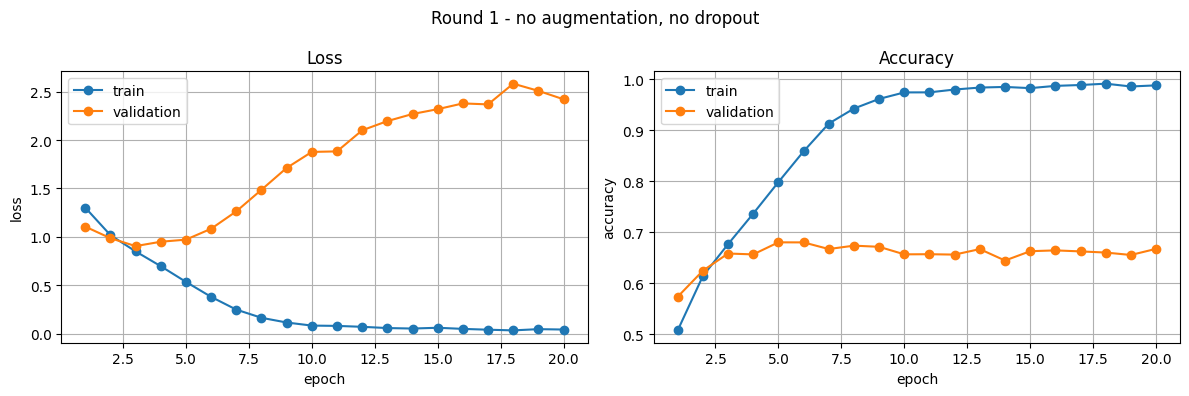

final train acc: 0.9883
final val acc  : 0.6673
gap            : 0.3211


In [14]:
# Curves for Round 1

def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='train')
    plt.plot(epochs, history['val_loss'], 'o-', label='validation')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'o-', label='train')
    plt.plot(epochs, history['val_acc'], 'o-', label='validation')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history1, 'Round 1 - no augmentation, no dropout')

gap1 = history1['train_acc'][-1] - history1['val_acc'][-1]
print('final train acc: %.4f' % history1['train_acc'][-1])
print('final val acc  : %.4f' % history1['val_acc'][-1])
print('gap            : %.4f' % gap1)



"""
## Round 1 - overfitting

Training accuracy keeps climbing towards 1.0 and training loss keeps falling, but
validation accuracy flattens out and validation loss stops falling and starts to
rise again. That growing distance between the two curves is overfitting: the
network is memorising the exact crops it was shown instead of learning what a
monitor or a keyboard generally looks like.

This is expected here. The photos come from only a handful of laboratory rooms at
one university, so the same monitor or the same chair appears again and again with
the same background and lighting, which is very easy for the network to memorise.
"""


In [15]:
# ROUND 2 data pipeline: simple transformations on the training set only

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

train_data_aug = datasets.ImageFolder(OUT + '/train', transform=train_transform)
train_loader_aug = DataLoader(train_data_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print('augmented training set ready:', len(train_data_aug))
print('validation and test stay unchanged (no augmentation)')


augmented training set ready: 28544
validation and test stay unchanged (no augmentation)


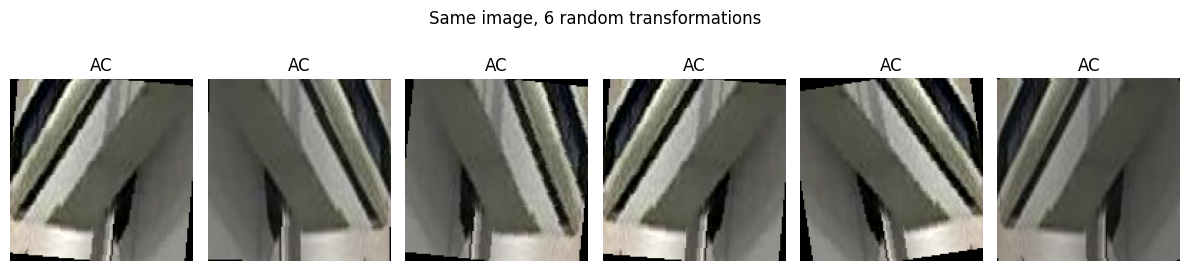

In [16]:
# The same image looks a little different every time it is loaded

plt.figure(figsize=(12, 3))
for i in range(6):
    img, lab = train_data_aug[0]
    plt.subplot(1, 6, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[lab])
    plt.axis('off')
plt.suptitle('Same image, 6 random transformations')
plt.tight_layout()
plt.show()



In [17]:
# ROUND 2: same CNN, now with dropout, trained on the transformed data

model2 = SimpleCNN(num_classes, p_drop=0.5).to(device)
history2 = run_training(model2, train_loader_aug, val_loader, EPOCHS)


Epoch 1 / 20 | train_loss 1.3418 train_acc 0.4858 | val_loss 1.1998 val_acc 0.5419
Epoch 2 / 20 | train_loss 1.1561 train_acc 0.5607 | val_loss 1.1186 val_acc 0.5670
Epoch 3 / 20 | train_loss 1.0788 train_acc 0.5871 | val_loss 1.0275 val_acc 0.6093
Epoch 4 / 20 | train_loss 1.0342 train_acc 0.5998 | val_loss 0.9979 val_acc 0.6124
Epoch 5 / 20 | train_loss 0.9932 train_acc 0.6197 | val_loss 0.9838 val_acc 0.6287
Epoch 6 / 20 | train_loss 0.9552 train_acc 0.6351 | val_loss 0.9545 val_acc 0.6358
Epoch 7 / 20 | train_loss 0.9347 train_acc 0.6400 | val_loss 0.9524 val_acc 0.6374
Epoch 8 / 20 | train_loss 0.9107 train_acc 0.6513 | val_loss 0.9253 val_acc 0.6501
Epoch 9 / 20 | train_loss 0.8816 train_acc 0.6579 | val_loss 0.8917 val_acc 0.6624
Epoch 10 / 20 | train_loss 0.8623 train_acc 0.6699 | val_loss 0.8642 val_acc 0.6773
Epoch 11 / 20 | train_loss 0.8457 train_acc 0.6733 | val_loss 0.8779 val_acc 0.6768
Epoch 12 / 20 | train_loss 0.8400 train_acc 0.6787 | val_loss 0.8626 val_acc 0.6826
E

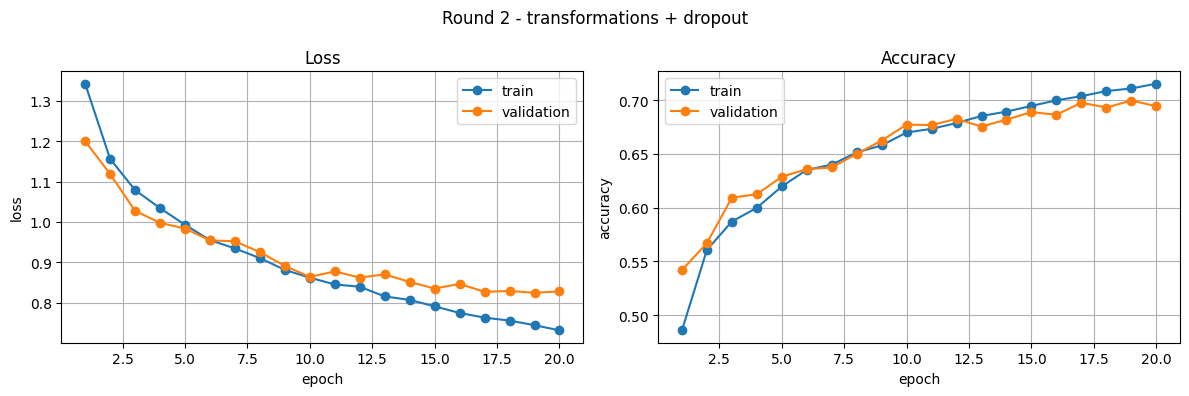

final train acc: 0.7153
final val acc  : 0.6944
gap            : 0.0210


In [18]:
plot_history(history2, 'Round 2 - transformations + dropout')

gap2 = history2['train_acc'][-1] - history2['val_acc'][-1]
print('final train acc: %.4f' % history2['train_acc'][-1])
print('final val acc  : %.4f' % history2['val_acc'][-1])
print('gap            : %.4f' % gap2)


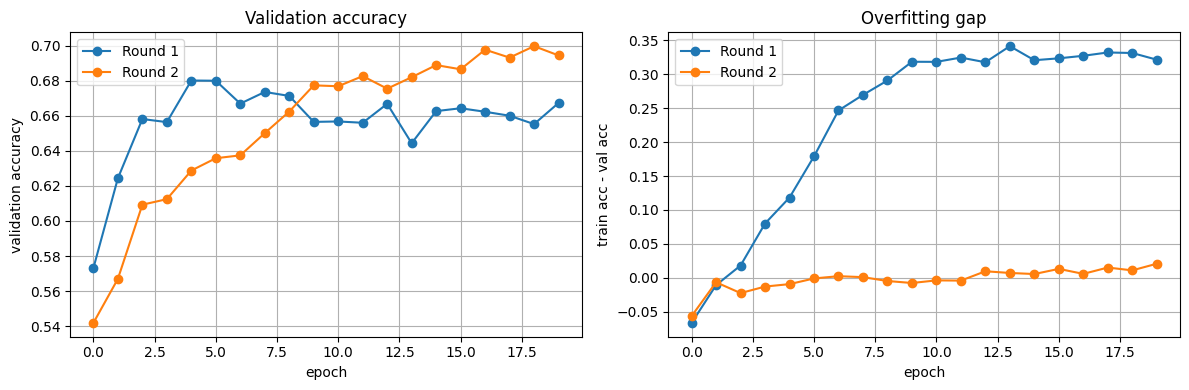

Round 1 -> best val acc 0.6801 | lowest val loss 0.9038 | final gap 0.3211
Round 2 -> best val acc 0.6996 | lowest val loss 0.8249 | final gap 0.0210


In [19]:
# Compare the two rounds

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1['val_acc'], 'o-', label='Round 1')
plt.plot(history2['val_acc'], 'o-', label='Round 2')
plt.xlabel('epoch')
plt.ylabel('validation accuracy')
plt.title('Validation accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
gaps1 = [a - b for a, b in zip(history1['train_acc'], history1['val_acc'])]
gaps2 = [a - b for a, b in zip(history2['train_acc'], history2['val_acc'])]
plt.plot(gaps1, 'o-', label='Round 1')
plt.plot(gaps2, 'o-', label='Round 2')
plt.xlabel('epoch')
plt.ylabel('train acc - val acc')
plt.title('Overfitting gap')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print('Round 1 -> best val acc %.4f | lowest val loss %.4f | final gap %.4f'
      % (max(history1['val_acc']), min(history1['val_loss']), gap1))
print('Round 2 -> best val acc %.4f | lowest val loss %.4f | final gap %.4f'
      % (max(history2['val_acc']), min(history2['val_loss']), gap2))


In [20]:
# Final check on the untouched test set

def predict_all(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            y_pred.extend(outputs.argmax(1).cpu().numpy())
            y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

true1, pred1 = predict_all(model1, test_loader)
true2, pred2 = predict_all(model2, test_loader)

print('Round 1 test accuracy: %.4f' % (true1 == pred1).mean())
print('Round 2 test accuracy: %.4f' % (true2 == pred2).mean())


Round 1 test accuracy: 0.6805
Round 2 test accuracy: 0.6987


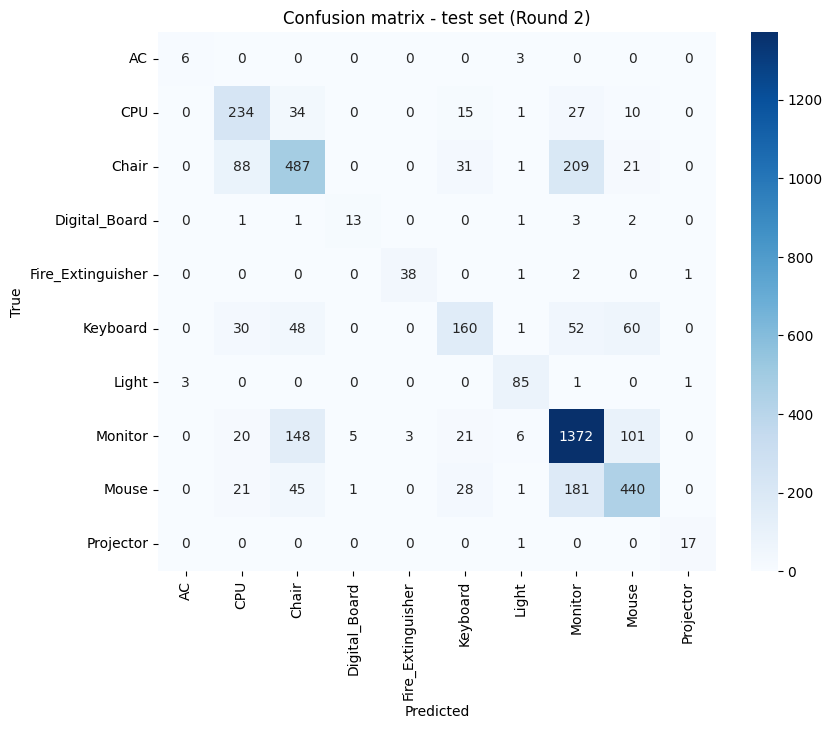

                   precision    recall  f1-score   support

               AC       0.67      0.67      0.67         9
              CPU       0.59      0.73      0.65       321
            Chair       0.64      0.58      0.61       837
    Digital_Board       0.68      0.62      0.65        21
Fire_Extinguisher       0.93      0.90      0.92        42
         Keyboard       0.63      0.46      0.53       351
            Light       0.84      0.94      0.89        90
          Monitor       0.74      0.82      0.78      1676
            Mouse       0.69      0.61      0.65       717
        Projector       0.89      0.94      0.92        18

         accuracy                           0.70      4082
        macro avg       0.73      0.73      0.73      4082
     weighted avg       0.70      0.70      0.69      4082



In [21]:
# Confusion matrix and per class report for the final model

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(true2, pred2)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix - test set (Round 2)')
plt.show()

print(classification_report(true2, pred2, target_names=class_names))


misclassified test crops: 1230


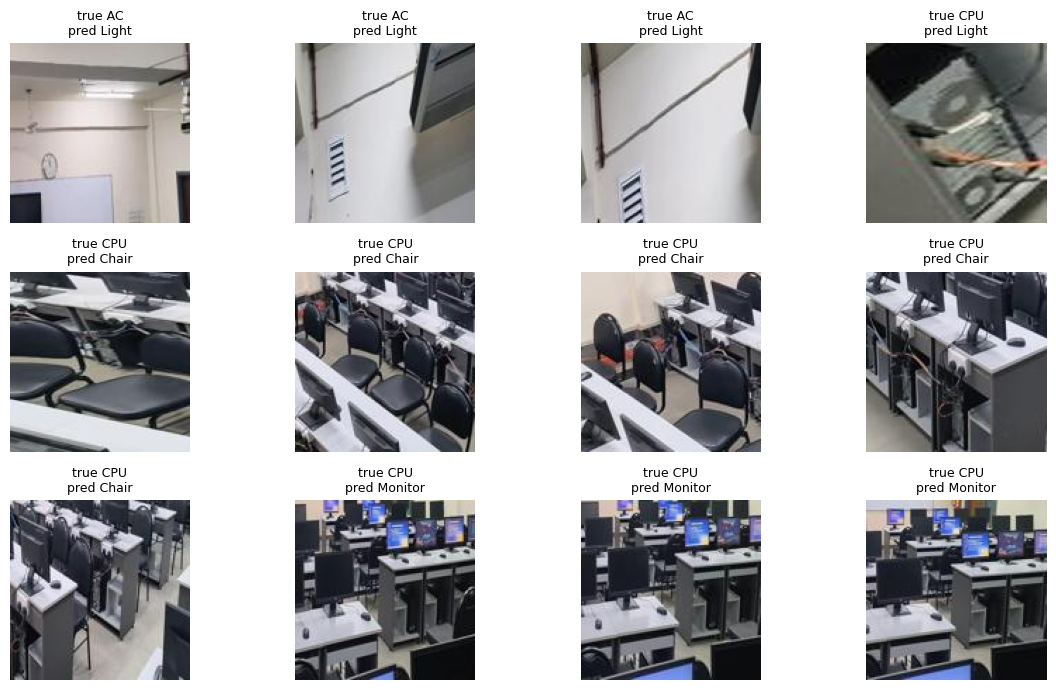

In [22]:
# Some wrong predictions of the final model

model2.eval()
wrong = []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model2(images.to(device))
        preds = outputs.argmax(1).cpu()
        for img, t, p in zip(images, labels, preds):
            if t != p:
                wrong.append((img, t.item(), p.item()))

print('misclassified test crops:', len(wrong))

show = min(12, len(wrong))
plt.figure(figsize=(12, 7))
for i in range(show):
    img, t, p = wrong[i]
    plt.subplot(3, 4, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title('true ' + class_names[t] + '\npred ' + class_names[p], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()



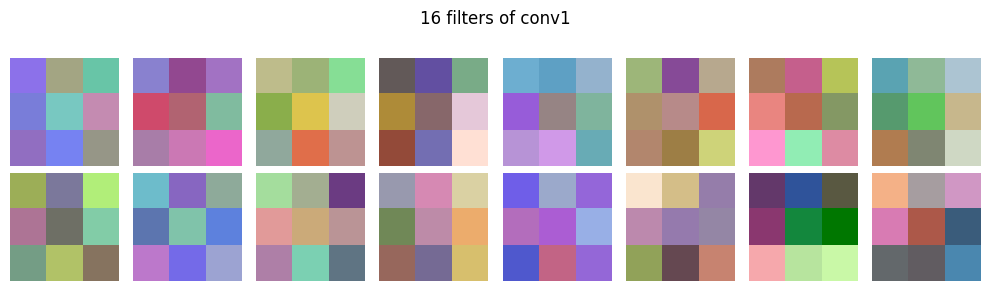

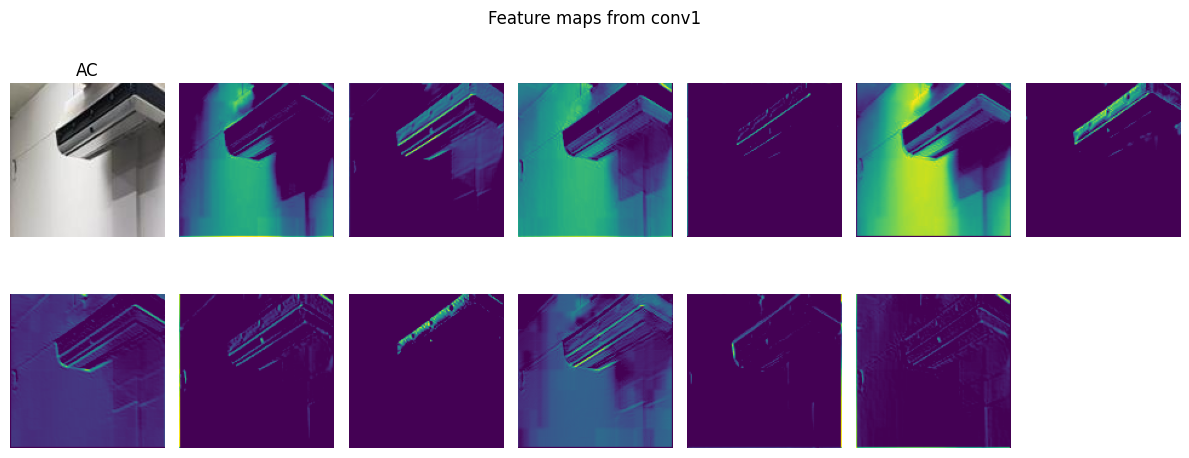

In [23]:
# What the first convolution layer learned

weights = model2.conv1.weight.data.cpu().clone()
weights = (weights - weights.min()) / (weights.max() - weights.min())

plt.figure(figsize=(10, 3))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(weights[i].permute(1, 2, 0))
    plt.axis('off')
plt.suptitle('16 filters of conv1')
plt.tight_layout()
plt.show()

img, lab = test_data[0]
x = img.unsqueeze(0).to(device)

model2.eval()
with torch.no_grad():
    maps = F.relu(model2.conv1(x)).cpu()[0]

plt.figure(figsize=(12, 5))
plt.subplot(2, 7, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title(class_names[lab])
plt.axis('off')
for i in range(12):
    plt.subplot(2, 7, i + 2)
    plt.imshow(maps[i], cmap='viridis')
    plt.axis('off')
plt.suptitle('Feature maps from conv1')
plt.tight_layout()
plt.show()



"""
## Result analysis

**Setup.** A CNN built from scratch: three convolution blocks (16, 32 and 64
filters, each 3x3, each followed by ReLU and 2x2 max pooling) and a classification
head of one hidden layer of 128 units and a 10 way output layer. Inputs are
128x128 RGB crops. Adam optimiser with learning rate 0.001, cross entropy loss,
batch size 64, 20 epochs. Both rounds use exactly the same architecture, optimiser
and number of epochs, so the only difference between them is the data
transformation and the dropout.

**Round 1 (no augmentation, no dropout).** Training accuracy rises close to 1.0
while validation accuracy stops improving early. Validation loss reaches a minimum
and then turns upward while training loss keeps falling. The distance between the
training and validation curves keeps widening, which is the classic picture of
overfitting.

**Round 2 (random horizontal flip, small rotation, brightness and contrast jitter,
plus dropout 0.5).** Training accuracy rises more slowly, because the network never
sees exactly the same image twice and dropout removes half of the hidden units at
every step. Validation loss keeps falling instead of turning upward, and the
train-minus-validation gap is clearly smaller than in Round 1 and stays flat
instead of growing. Validation and test accuracy are also higher, so the smaller
gap is not simply the training accuracy being pulled down.

**Evidence that overfitting is controlled.**
1. The gap plot in Cell 18 keeps rising in Round 1 but stays low and flat in Round 2.
2. Validation loss turns upward in Round 1 and keeps decreasing in Round 2.
3. Accuracy on the held out 10 percent test split, which neither model ever saw
   during training, is higher for Round 2.

**Remaining errors.** The confusion matrix shows the errors are mostly between
items that look alike inside a cropped box: CPU and monitor seen from the side are
both dark rectangles, and keyboard and digital board are both wide flat shapes. The
classes are also not balanced, because a lab photo contains many chairs and monitors
but only one AC or one projector, so the rare classes have lower recall. Using
class weights in the loss, or collecting more crops of the rare classes, would be
the next step.
"""
